## 2. Filtrer les marques européennes courantes

In [4]:
from pathlib import Path
import os

# Adapter le chemin si nécessaire
VMMRDB_PATH = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb")

# Voir la structure
print("=== STRUCTURE DU DATASET ===")
print(f"Chemin: {VMMRDB_PATH}")

# Lister les dossiers (marques)
makes = [d for d in VMMRDB_PATH.iterdir() if d.is_dir()]
print(f"\nNombre de marques: {len(makes)}")

# Afficher les 20 premières marques
print("\nExemples de marques:")
for make in sorted(makes)[:20]:
    print(f"  - {make.name}")

=== STRUCTURE DU DATASET ===
Chemin: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb

Nombre de marques: 9170

Exemples de marques:
  - acura_cl_1997
  - acura_cl_1998
  - acura_cl_1999
  - acura_cl_2001
  - acura_cl_2002
  - acura_cl_2003
  - acura_el_1997
  - acura_el_2001
  - acura_el_2003
  - acura_ilx_2013
  - acura_ilx_2014
  - acura_integra_1900
  - acura_integra_1986
  - acura_integra_1987
  - acura_integra_1988
  - acura_integra_1989
  - acura_integra_1990
  - acura_integra_1991
  - acura_integra_1992
  - acura_integra_1993


## extrayons les marques uniques et filtrons les européennes

In [5]:
from pathlib import Path
from collections import Counter

VMMRDB_PATH = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb")

# Extraire toutes les marques uniques (premier élément avant _)
all_folders = [d.name for d in VMMRDB_PATH.iterdir() if d.is_dir()]

# Extraire la marque (tout avant le premier _ suivi du modèle)
makes = []
for folder in all_folders:
    parts = folder.split('_')
    make = parts[0]
    makes.append(make)

# Compter les images par marque
make_counts = Counter(makes)

print(f"=== MARQUES UNIQUES: {len(make_counts)} ===\n")

# Afficher toutes les marques triées par nombre d'images
print("Toutes les marques (triées par fréquence):")
for make, count in make_counts.most_common():
    print(f"  {make}: {count} dossiers")

=== MARQUES UNIQUES: 75 ===

Toutes les marques (triées par fréquence):
  chevrolet: 1013 dossiers
  ford: 870 dossiers
  toyota: 584 dossiers
  mercedes benz: 474 dossiers
  dodge: 452 dossiers
  bmw: 442 dossiers
  gmc: 344 dossiers
  volkswagen: 327 dossiers
  nissan: 316 dossiers
  honda: 292 dossiers
  mazda: 280 dossiers
  pontiac: 266 dossiers
  jeep: 230 dossiers
  buick: 221 dossiers
  volvo: 198 dossiers
  lexus: 196 dossiers
  cadillac: 194 dossiers
  chrysler: 169 dossiers
  audi: 162 dossiers
  mercury: 161 dossiers
  hyundai: 150 dossiers
  mitsubishi: 150 dossiers
  lincoln: 148 dossiers
  oldsmobile: 142 dossiers
  subaru: 137 dossiers
  acura: 129 dossiers
  kia: 124 dossiers
  saturn: 115 dossiers
  infiniti: 110 dossiers
  plymouth: 109 dossiers
  suzuki: 89 dossiers
  porsche: 79 dossiers
  jaguar: 77 dossiers
  isuzu: 66 dossiers
  landrover: 52 dossiers
  saab: 43 dossiers
  scion: 33 dossiers
  ram: 25 dossiers
  mini: 20 dossiers
  fiat: 15 dossiers
  daewoo: 14

## Filtrage des marques europeen

In [6]:
from pathlib import Path
from collections import defaultdict

VMMRDB_PATH = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb")

# Marques courantes en Europe
european_makes = [
    # Allemandes
    'mercedes benz', 'bmw', 'volkswagen', 'audi', 'porsche', 'opel', 'mini',
    # Françaises
    'renault', 'peugeot', 'citroen',
    # Italiennes
    'fiat', 'alfa romeo', 'ferrari', 'maserati', 'lamborghini',
    # Britanniques
    'jaguar', 'landrover', 'bentley', 'rollsroyce', 'aston martin', 'lotus',
    # Suédoises
    'volvo', 'saab',
    # Asiatiques (très présentes en Europe)
    'toyota', 'nissan', 'honda', 'mazda', 'hyundai', 'kia', 'mitsubishi', 'suzuki',
    # Américaines présentes en Europe
    'ford'
]

# Compter les IMAGES par marque
make_image_counts = defaultdict(int)
make_folders = defaultdict(list)

for folder in VMMRDB_PATH.iterdir():
    if folder.is_dir():
        make = folder.name.split('_')[0]
        if make in european_makes:
            # Compter les images dans ce dossier
            images = list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
            make_image_counts[make] += len(images)
            make_folders[make].append(folder.name)

# Afficher les résultats
print("=== MARQUES EUROPÉENNES - NOMBRE D'IMAGES ===\n")

total_images = 0
for make, count in sorted(make_image_counts.items(), key=lambda x: -x[1]):
    print(f"  {make}: {count:,} images ({len(make_folders[make])} dossiers)")
    total_images += count

print(f"\n{'='*50}")
print(f"TOTAL: {total_images:,} images pour {len(make_image_counts)} marques")

KeyboardInterrupt: 

## Selection des marques avec suffisement de données

In [ ]:
from pathlib import Path
from collections import defaultdict
import shutil
import random

VMMRDB_PATH = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb")
OUTPUT_PATH = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_europe")

# Marques avec assez d'images (>500)
selected_makes = [
    'ford', 'toyota', 'honda', 'nissan', 'volkswagen', 
    'bmw', 'hyundai', 'mazda', 'mercedes benz', 'kia',
    'mitsubishi', 'audi', 'volvo', 'mini', 'suzuki',
    'jaguar', 'porsche', 'landrover', 'saab'
]

# Paramètres
MAX_IMAGES_PER_MAKE = 1000  # Équilibrer les classes
MIN_IMAGES_PER_MAKE = 500

print("=== CRÉATION DU DATASET ÉQUILIBRÉ ===\n")

# Créer le dossier de sortie
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Collecter et copier les images
for make in selected_makes:
    make_output = OUTPUT_PATH / make
    make_output.mkdir(exist_ok=True)
    
    # Collecter toutes les images de cette marque
    all_images = []
    for folder in VMMRDB_PATH.iterdir():
        if folder.is_dir() and folder.name.split('_')[0] == make:
            images = list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
            all_images.extend(images)
    
    # Limiter à MAX_IMAGES_PER_MAKE
    if len(all_images) > MAX_IMAGES_PER_MAKE:
        all_images = random.sample(all_images, MAX_IMAGES_PER_MAKE)
    
    # Copier les images
    for i, img_path in enumerate(all_images):
        dest = make_output / f"{make}_{i:04d}.jpg"
        shutil.copy2(img_path, dest)
    
    print(f"  ✅ {make}: {len(all_images)} images copiées")

print(f"\n{'='*50}")
print(f"Dataset créé dans: {OUTPUT_PATH}")

=== CRÉATION DU DATASET ÉQUILIBRÉ ===

  ✅ ford: 1000 images copiées
  ✅ toyota: 1000 images copiées
  ✅ honda: 1000 images copiées
  ✅ nissan: 1000 images copiées
  ✅ volkswagen: 1000 images copiées
  ✅ bmw: 1000 images copiées
  ✅ hyundai: 1000 images copiées
  ✅ mazda: 1000 images copiées
  ✅ mercedes benz: 1000 images copiées
  ✅ kia: 1000 images copiées
  ✅ mitsubishi: 1000 images copiées
  ✅ audi: 1000 images copiées
  ✅ volvo: 1000 images copiées
  ✅ mini: 1000 images copiées
  ✅ suzuki: 1000 images copiées
  ✅ jaguar: 951 images copiées
  ✅ porsche: 895 images copiées
  ✅ landrover: 619 images copiées
  ✅ saab: 614 images copiées

Dataset créé dans: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_europe


## Scrapping image voiture francaise 

In [ ]:
import os
import requests
import time
from pathlib import Path
from urllib.parse import quote
import re

def download_car_images_by_model(make, models, num_images_per_model=50, output_dir="VMMRdb_europe"):
    """
    Télécharge des images par modèle (pour avoir les labels)
    """
    make_path = Path(output_dir) / make.lower().replace(' ', '_')
    make_path.mkdir(parents=True, exist_ok=True)
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    
    total_downloaded = 0
    
    for model in models:
        model_clean = model.lower().replace(' ', '_')
        
        # Compter les images existantes pour ce modèle
        existing = len(list(make_path.glob(f"{model_clean}_*.jpg")))
        if existing >= num_images_per_model:
            print(f"    ⏭️  {make} {model}: déjà {existing} images")
            total_downloaded += existing
            continue
        
        queries = [
            f"{make} {model}",
            f"{make} {model} car",
            f"{make} {model} 2023",
            f"{make} {model} 2022",
            f"{make} {model} front",
        ]
        
        downloaded = existing
        
        for query in queries:
            if downloaded >= num_images_per_model:
                break
                
            try:
                url = f"https://www.bing.com/images/search?q={quote(query)}&form=HDRSC2&first=1"
                response = requests.get(url, headers=headers, timeout=15)
                
                img_urls = re.findall(r'murl&quot;:&quot;(https?://[^&]+\.(?:jpg|jpeg|png))', response.text)
                
                for img_url in img_urls[:50]:
                    if downloaded >= num_images_per_model:
                        break
                        
                    try:
                        img_response = requests.get(img_url, headers=headers, timeout=10)
                        if img_response.status_code == 200 and len(img_response.content) > 5000:
                            # Nom: modele_xxxx.jpg pour garder le label
                            img_path = make_path / f"{model_clean}_{downloaded:04d}.jpg"
                            with open(img_path, 'wb') as f:
                                f.write(img_response.content)
                            downloaded += 1
                    except:
                        continue
                        
                    time.sleep(0.1)
                    
            except Exception as e:
                continue
                
            time.sleep(0.3)
        
        print(f"    ✅ {make} {model}: {downloaded} images")
        total_downloaded += downloaded
    
    print(f"  📊 {make} TOTAL: {total_downloaded} images\n")
    return total_downloaded


# === MODÈLES COURANTS PAR MARQUE ===

french_cars = {
    'Renault': [
        'Clio', 'Megane', 'Captur', 'Kadjar', 'Scenic', 
        'Twingo', 'Arkana', 'Austral', 'Espace', 'Talisman',
        'Zoe', 'Kangoo', 'Trafic', 'Master'
    ],
    'Peugeot': [
        '108', '208', '308', '408', '508',
        '2008', '3008', '5008',
        'Rifter', 'Partner', 'Expert', 'Boxer'
    ],
    'Citroen': [
        'C1', 'C3', 'C4', 'C5',
        'C3 Aircross', 'C4 Cactus', 'C5 Aircross',
        'Berlingo', 'Jumpy', 'Jumper', 'DS3', 'DS4', 'DS7'
    ]
}

OUTPUT_DIR = "/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_europe"

print("=== SCRAPING MARQUES FRANÇAISES PAR MODÈLE ===\n")

for make, models in french_cars.items():
    print(f"🚗 {make} ({len(models)} modèles)")
    download_car_images_by_model(make, models, num_images_per_model=40, output_dir=OUTPUT_DIR)

print("✅ Terminé !")
# ```

# **Structure des fichiers :**
# ```
# VMMRdb_europe/
# ├── renault/
# │   ├── clio_0000.jpg
# │   ├── clio_0001.jpg
# │   ├── megane_0000.jpg
# │   ├── captur_0000.jpg
# │   └── ...
# ├── peugeot/
# │   ├── 208_0000.jpg
# │   ├── 308_0000.jpg
# │   └── ...
# └── citroen/
#     ├── c3_0000.jpg
#     └── ...

=== SCRAPING MARQUES FRANÇAISES PAR MODÈLE ===

🚗 Renault (14 modèles)
    ✅ Renault Clio: 40 images
    ✅ Renault Megane: 40 images
    ✅ Renault Captur: 40 images
    ✅ Renault Kadjar: 40 images
    ✅ Renault Scenic: 40 images
    ✅ Renault Twingo: 40 images
    ✅ Renault Arkana: 40 images
    ✅ Renault Austral: 40 images
    ✅ Renault Espace: 40 images
    ✅ Renault Talisman: 40 images
    ✅ Renault Zoe: 40 images
    ✅ Renault Kangoo: 40 images
    ✅ Renault Trafic: 40 images
    ✅ Renault Master: 40 images
  📊 Renault TOTAL: 560 images

🚗 Peugeot (12 modèles)
    ✅ Peugeot 108: 40 images
    ✅ Peugeot 208: 40 images
    ✅ Peugeot 308: 40 images
    ✅ Peugeot 408: 40 images
    ✅ Peugeot 508: 40 images
    ✅ Peugeot 2008: 40 images
    ✅ Peugeot 3008: 40 images
    ✅ Peugeot 5008: 40 images
    ✅ Peugeot Rifter: 40 images
    ✅ Peugeot Partner: 40 images
    ✅ Peugeot Expert: 40 images
    ✅ Peugeot Boxer: 40 images
  📊 Peugeot TOTAL: 480 images

🚗 Citroen (13 modèles)
    ✅ Citroe

In [ ]:
from pathlib import Path
from collections import defaultdict

OUTPUT_DIR = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_europe")

print("=== RÉCAPITULATIF DATASET VMMRdb_europe ===\n")

total_images = 0
make_counts = {}

for make_dir in sorted(OUTPUT_DIR.iterdir()):
    if make_dir.is_dir():
        images = list(make_dir.glob("*.jpg")) + list(make_dir.glob("*.png"))
        count = len(images)
        make_counts[make_dir.name] = count
        total_images += count

# Afficher trié par nombre d'images
print(f"{'Marque':<20} {'Images':>10}")
print("-" * 32)

for make, count in sorted(make_counts.items(), key=lambda x: -x[1]):
    print(f"{make:<20} {count:>10}")

print("-" * 32)
print(f"{'TOTAL':<20} {total_images:>10}")
print(f"\n📊 {len(make_counts)} marques")

=== RÉCAPITULATIF DATASET VMMRdb_europe ===

Marque                   Images
--------------------------------
audi                       1000
bmw                        1000
ford                       1000
honda                      1000
hyundai                    1000
kia                        1000
mazda                      1000
mercedes benz              1000
mini                       1000
mitsubishi                 1000
nissan                     1000
suzuki                     1000
toyota                     1000
volkswagen                 1000
volvo                      1000
jaguar                      951
porsche                     895
peugeot                     815
renault                     715
landrover                   619
saab                        614
citroen                     520
--------------------------------
TOTAL                     20129

📊 22 marques


## Création du train, test, split

In [ ]:
import os
import shutil
import random
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# Chemins
SOURCE_DIR = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_europe")
OUTPUT_DIR = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split")

# Créer les dossiers
for split in ['train', 'val', 'test']:
    (OUTPUT_DIR / split).mkdir(parents=True, exist_ok=True)

print("=== CRÉATION DU SPLIT TRAIN/VAL/TEST ===\n")

# Collecter toutes les images avec leurs labels
data = []

for make_dir in SOURCE_DIR.iterdir():
    if make_dir.is_dir():
        make = make_dir.name
        for img_path in make_dir.glob("*.jpg"):
            data.append({
                'image_path': img_path,
                'image_name': img_path.name,
                'make': make
            })

print(f"📊 Total images collectées: {len(data)}")

# Créer DataFrame
df = pd.DataFrame(data)

# Split stratifié: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['make'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['make'], random_state=42
)

print(f"\n📊 Split:")
print(f"   Train: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Val:   {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test:  {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")

# Copier les images dans les dossiers
print("\n📁 Copie des images...")

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    split_df = split_df.copy()
    new_paths = []
    
    for idx, row in split_df.iterrows():
        src = row['image_path']
        # Nouveau nom: make_originalname.jpg
        new_name = f"{row['make']}_{row['image_name']}"
        dst = OUTPUT_DIR / split_name / new_name
        shutil.copy2(src, dst)
        new_paths.append(dst.name)
    
    split_df['new_image_name'] = new_paths
    print(f"   ✅ {split_name}: {len(split_df)} images copiées")

# Créer le CSV des labels
print("\n📄 Création du CSV des labels...")

# Recréer les DataFrames avec les nouveaux noms
train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

all_df = pd.concat([train_df, val_df, test_df])
all_df['new_image_name'] = all_df['make'] + '_' + all_df['image_name']

# Sauvegarder le CSV
labels_df = all_df[['new_image_name', 'make', 'split']].copy()
labels_df.columns = ['image_name', 'make', 'split']
labels_df.to_csv(OUTPUT_DIR / 'labels.csv', index=False)

print(f"   ✅ labels.csv créé: {len(labels_df)} entrées")

# Résumé par marque
print("\n📊 Distribution par marque (train):")
print(train_df['make'].value_counts().head(10))

print("\n✅ Dataset prêt pour l'entraînement !")
print(f"📁 Chemin: {OUTPUT_DIR}")
# ```

# Lance ça et on aura :
# ```
# VMMRdb_split/
# ├── train/          (~14,000 images)
# ├── val/            (~3,000 images)
# ├── test/           (~3,000 images)
# └── labels.csv      (image_name, make, split)

=== CRÉATION DU SPLIT TRAIN/VAL/TEST ===

📊 Total images collectées: 20129

📊 Split:
   Train: 14090 images (70.0%)
   Val:   3019 images (15.0%)
   Test:  3020 images (15.0%)

📁 Copie des images...
   ✅ train: 14090 images copiées
   ✅ val: 3019 images copiées
   ✅ test: 3020 images copiées

📄 Création du CSV des labels...
   ✅ labels.csv créé: 20129 entrées

📊 Distribution par marque (train):
make
bmw              700
volkswagen       700
mercedes benz    700
hyundai          700
nissan           700
mitsubishi       700
toyota           700
mini             700
mazda            700
suzuki           700
Name: count, dtype: int64

✅ Dataset prêt pour l'entraînement !
📁 Chemin: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split


#  Fine tuning


In [7]:
# === CELLULE 1: IMPORTS ===
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import pandas as pd
import cv2
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("✅ Imports OK")

✅ Imports OK


In [8]:
# === CELLULE 2: CONFIGURATION ===
DATA_DIR = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split")
MODEL_DIR = Path("models/efficientnet_vmmrdb")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparamètres
CONFIG = {
    'epochs': 20,
    'batch_size': 32,
    'lr': 1e-4,
    'img_size': 224,
    'num_workers': 4,
    'patience': 5,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")
print(f"📁 Data: {DATA_DIR}")
print(f"📁 Model: {MODEL_DIR}")

🖥️ Device: cuda
📁 Data: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split
📁 Model: models/efficientnet_vmmrdb


In [9]:
# === CELLULE 3: CHARGER LES LABELS ===
df = pd.read_csv(DATA_DIR / 'labels.csv')

# Encoder les marques
label_encoder = LabelEncoder()
label_encoder.fit(df['make'])
df['class_id'] = label_encoder.transform(df['make'])

num_classes = len(label_encoder.classes_)
print(f"✅ {len(df)} images, {num_classes} classes")
print(f"\nClasses: {list(label_encoder.classes_)}")

# Split
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

print(f"\n📊 Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

✅ 20129 images, 22 classes

Classes: ['audi', 'bmw', 'citroen', 'ford', 'honda', 'hyundai', 'jaguar', 'kia', 'landrover', 'mazda', 'mercedes benz', 'mini', 'mitsubishi', 'nissan', 'peugeot', 'porsche', 'renault', 'saab', 'suzuki', 'toyota', 'volkswagen', 'volvo']

📊 Train: 14090 | Val: 3019 | Test: 3020


In [10]:
# === VÉRIFIER ET NETTOYER LES IMAGES CORROMPUES ===
import cv2
from pathlib import Path
from tqdm import tqdm

DATA_DIR = Path("/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split")

print("=== VÉRIFICATION DES IMAGES ===\n")

corrupted = []

for split in ['train', 'val', 'test']:
    split_dir = DATA_DIR / split
    images = list(split_dir.glob("*.jpg")) + list(split_dir.glob("*.png"))
    
    print(f"🔍 Vérification {split}: {len(images)} images...")
    
    for img_path in tqdm(images, desc=split):
        img = cv2.imread(str(img_path))
        if img is None:
            corrupted.append(img_path)

print(f"\n❌ Images corrompues: {len(corrupted)}")

if corrupted:
    print("\nSuppression des images corrompues...")
    for img_path in corrupted:
        print(f"  🗑️ {img_path.name}")
        img_path.unlink()  # Supprimer le fichier
    print(f"\n✅ {len(corrupted)} fichiers supprimés")
else:
    print("✅ Toutes les images sont valides")

=== VÉRIFICATION DES IMAGES ===

🔍 Vérification train: 14083 images...


train: 100%|██████████| 14083/14083 [02:16<00:00, 103.55it/s]


🔍 Vérification val: 3018 images...


val: 100%|██████████| 3018/3018 [00:30<00:00, 98.33it/s] 


🔍 Vérification test: 3019 images...


test: 100%|██████████| 3019/3019 [00:31<00:00, 97.01it/s] 


❌ Images corrompues: 0
✅ Toutes les images sont valides


In [11]:
# === CELLULE 4: DATASET & TRANSFORMS (CORRIGÉ) ===
class VehicleDataset(Dataset):
    def __init__(self, dataframe, data_dir, split, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.data_dir = Path(data_dir) / split
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.data_dir / row['image_name']
        
        image = cv2.imread(str(img_path))
        
        # Vérifier si l'image est valide
        if image is None:
            # Retourner une image noire en cas d'erreur
            print(f"⚠️ Image non lisible: {img_path}")
            image = np.zeros((CONFIG['img_size'], CONFIG['img_size'], 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image=image)['image']
        
        label = row['class_id']
        return image, label

# Transforms
train_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Datasets
train_dataset = VehicleDataset(train_df, DATA_DIR, 'train', train_transform)
val_dataset = VehicleDataset(val_df, DATA_DIR, 'val', val_transform)

print(f"✅ Train: {len(train_dataset)} | Val: {len(val_dataset)}")

✅ Train: 14090 | Val: 3019


/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/alpr_env/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [12]:
# === CELLULE 5: DATALOADERS (CORRIGÉ) ===
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,  # Mis à 0 pour éviter les erreurs sur WSL
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,  # Mis à 0 pour éviter les erreurs sur WSL
    pin_memory=True
)

print(f"✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

✅ Train batches: 441 | Val batches: 95


In [13]:
# === CELLULE 6: MODÈLE ===
# Charger EfficientNet pré-entraîné ImageNet
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Remplacer le classifier pour nos classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(1280, num_classes)
)

model = model.to(device)
print(f"✅ EfficientNet-B0 chargé ({num_classes} classes)")

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Paramètres: {total_params:,} (trainable: {trainable_params:,})")

✅ EfficientNet-B0 chargé (22 classes)
   Paramètres: 4,035,730 (trainable: 4,035,730)


In [14]:
# === CELLULE 7: ENTRAÎNEMENT ===
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Train')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Val'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

print("✅ Fonctions d'entraînement prêtes")

✅ Fonctions d'entraînement prêtes


In [15]:
# === CELLULE 8: BOUCLE D'ENTRAÎNEMENT ===
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0

print("=" * 60)
print(f"🚀 DÉMARRAGE ENTRAÎNEMENT - {num_classes} classes, {len(train_dataset)} images")
print("=" * 60)

for epoch in range(CONFIG['epochs']):
    print(f"\n📊 Epoch {epoch+1}/{CONFIG['epochs']}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_acc)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Sauvegarder le meilleur modèle
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'num_classes': num_classes,
            'label_encoder_classes': list(label_encoder.classes_),
        }, MODEL_DIR / 'best_model_vmmrdb.pth')
        
        print(f"💾 Meilleur modèle sauvegardé! Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1
    
    if patience_counter >= CONFIG['patience']:
        print(f"\n⏹️ Early stopping à epoch {epoch+1}")
        break

print("\n" + "=" * 60)
print(f"🎉 ENTRAÎNEMENT TERMINÉ! Meilleure Val Acc: {best_val_acc:.2f}%")
print("=" * 60)

🚀 DÉMARRAGE ENTRAÎNEMENT - 22 classes, 14090 images

📊 Epoch 1/20


Train:   6%|▌         | 27/441 [00:14<03:18,  2.08it/s, loss=3.0019, acc=6.94%]

⚠️ Image non lisible: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split/train/citroen_ds3_0036.jpg


[ WARN:0@415.536] global loadsave.cpp:278 findDecoder imread_('/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split/train/citroen_ds3_0036.jpg'): can't open/read file: check file path/integrity
Train:  27%|██▋       | 117/441 [00:56<02:25,  2.23it/s, loss=2.8897, acc=11.46%][ WARN:0@457.688] global loadsave.cpp:278 findDecoder imread_('/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split/train/citroen_ds3_0039.jpg'): can't open/read file: check file path/integrity


⚠️ Image non lisible: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split/train/citroen_ds3_0039.jpg


...

⚠️ Image non lisible: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split/train/citroen_c1_0007.jpg


Val:  47%|████▋     | 45/95 [00:18<00:21,  2.32it/s][ WARN:0@5234.110] global loadsave.cpp:278 findDecoder imread_('/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split/val/peugeot_peugeot_0225.jpg'): can't open/read file: check file path/integrity


⚠️ Image non lisible: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split/val/peugeot_peugeot_0225.jpg


Val: 100%|██████████| 95/95 [00:39<00:00,  2.42it/s]

Train Loss: 0.0760 | Train Acc: 97.73%
Val Loss: 0.7596 | Val Acc: 82.54%

🎉 ENTRAÎNEMENT TERMINÉ! Meilleure Val Acc: 82.58%


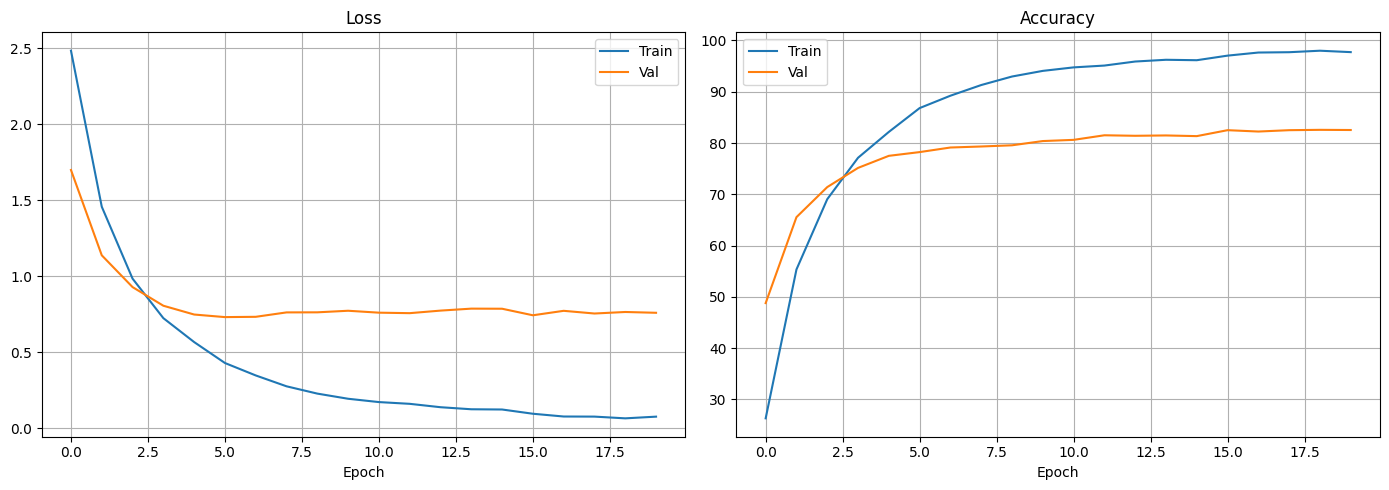

In [16]:
# === CELLULE 9: COURBES D'ENTRAÎNEMENT ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_curves.png', dpi=150)
plt.show()

In [17]:
# === CELLULE 10: TEST FINAL ===
# Charger le meilleur modèle
checkpoint = torch.load(MODEL_DIR / 'best_model_vmmrdb.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Évaluer sur le test set
test_dataset = VehicleDataset(test_df, DATA_DIR, 'test', val_transform)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"\n🎯 TEST ACCURACY: {test_acc:.2f}%")

Val:   8%|▊         | 8/95 [00:04<00:38,  2.25it/s]

⚠️ Image non lisible: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/VMMRdb_split/test/citroen_ds3_0037.jpg


Val: 100%|██████████| 95/95 [00:43<00:00,  2.20it/s]


🎯 TEST ACCURACY: 82.68%
